# Прогнозирование показателей деятельности предприятия

Этот ноутбук строго соответствует ТЗ:
1. Подготовка временного ряда (полнота, пропуски, сезонность, график динамики).
2. Модели: линейная регрессия, полиномиальная регрессия, экспоненциальное сглаживание.
3. Метрики: MAE, MSE, RMSE, MAPE.
4. Визуализация: факт/прогноз и сравнение моделей.
5. После каждого графика дается пояснение, что на нем показано.
6. После выполнения автоматически формируется отдельный markdown-отчет.


## 1. Импорт библиотек


In [1]:
# Если в Colab не хватает библиотек, раскомментируйте:
# !pip -q install pandas numpy matplotlib scikit-learn statsmodels

from pathlib import Path
from datetime import datetime
import warnings
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.seasonal import seasonal_decompose

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')




## 2. Загрузка данных (локально и Colab)


In [2]:
DEFAULT_LOCAL_PATH = Path(r'C:\Users\moskv\Downloads\PP13_ISP22_timeseries.csv')
DEFAULT_COLAB_PATH = Path('/content/PP13_ISP22_timeseries.csv')

DATA_PATH = None

try:
    from google.colab import files  # type: ignore
    if DEFAULT_COLAB_PATH.exists():
        DATA_PATH = DEFAULT_COLAB_PATH
    else:
        print('Загрузите CSV в Colab')
        uploaded = files.upload()
        if uploaded:
            DATA_PATH = Path(next(iter(uploaded.keys())))
except Exception:
    if DEFAULT_LOCAL_PATH.exists():
        DATA_PATH = DEFAULT_LOCAL_PATH

if DATA_PATH is None:
    raise FileNotFoundError('CSV не найден. Укажите путь вручную в DATA_PATH.')

print(f'Используется файл: {DATA_PATH.resolve()}')
df_raw = pd.read_csv(DATA_PATH)
print('Размер набора:', df_raw.shape)
display(df_raw.head())


Загрузите CSV в Colab


Saving PP13_ISP22_timeseries.csv to PP13_ISP22_timeseries.csv
Используется файл: /content/PP13_ISP22_timeseries.csv
Размер набора: (36, 2)


,date,monthly_sales
0,2021-01-31,"95,799.45"
1,2021-02-28,"107,537.77"
2,2021-03-31,"110,276.15"
3,2021-04-30,"118,061.86"
4,2021-05-31,"118,234.89"


## 3. Подготовка временного ряда


In [3]:
required_cols = {'date', 'monthly_sales'}
missing_cols = required_cols.difference(df_raw.columns)
if missing_cols:
    raise ValueError(f'Отсутствуют обязательные столбцы: {missing_cols}')

df = df_raw.copy()
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['monthly_sales'] = pd.to_numeric(df['monthly_sales'], errors='coerce')
df = df.sort_values('date')

quality_report = {
    'rows_before': len(df),
    'missing_date_before': int(df['date'].isna().sum()),
    'missing_value_before': int(df['monthly_sales'].isna().sum()),
    'duplicate_dates_before': int(df['date'].duplicated().sum())
}

if quality_report['duplicate_dates_before'] > 0:
    df = df.groupby('date', as_index=False)['monthly_sales'].mean()

full_index = pd.date_range(start=df['date'].min(), end=df['date'].max(), freq='M')
df = df.set_index('date').reindex(full_index)
df.index.name = 'date'
quality_report['expected_points'] = len(full_index)
quality_report['missing_after_reindex'] = int(df['monthly_sales'].isna().sum())

df['monthly_sales'] = df['monthly_sales'].interpolate(method='linear').ffill().bfill()
quality_report['missing_after_fill'] = int(df['monthly_sales'].isna().sum())

q1 = df['monthly_sales'].quantile(0.25)
q3 = df['monthly_sales'].quantile(0.75)
iqr = q3 - q1
low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
quality_report['iqr_outliers'] = int(((df['monthly_sales'] < low) | (df['monthly_sales'] > high)).sum())

display(pd.DataFrame.from_dict(quality_report, orient='index', columns=['value']))

ts = df['monthly_sales'].astype(float)
print('Диапазон дат:', ts.index.min().date(), '->', ts.index.max().date())
print('Количество наблюдений:', len(ts))


,value
rows_before,36
missing_date_before,0
missing_value_before,0
duplicate_dates_before,0
expected_points,36
missing_after_reindex,0
missing_after_fill,0
iqr_outliers,0


Диапазон дат: 2021-01-31 -> 2023-12-31
Количество наблюдений: 36


## 4. Анализ динамики и сезонности


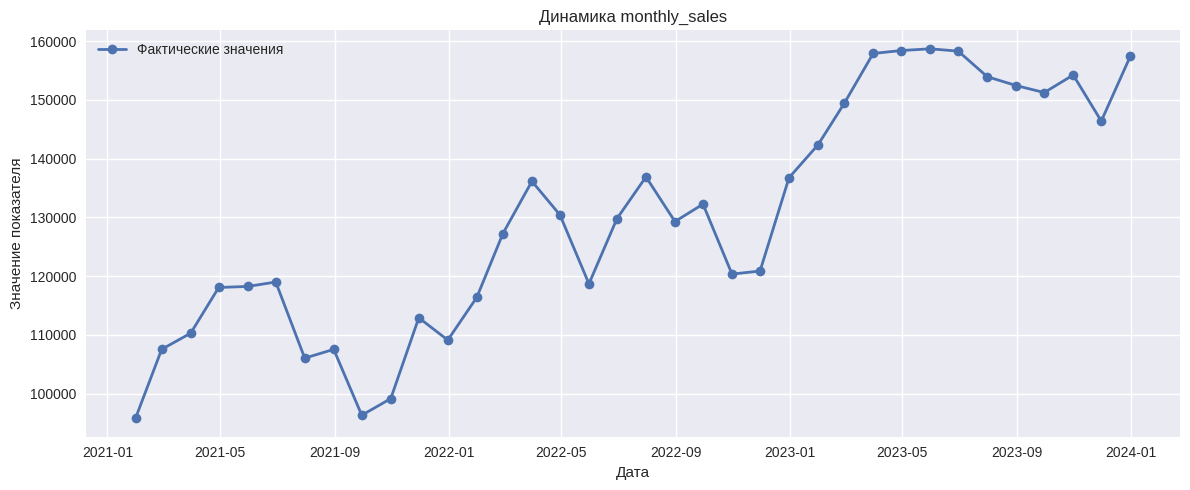

Пояснение к графику 1:
- Линия показывает изменение monthly_sales по месяцам.
- На старте: 95,799.45; на конце: 157,402.81; общий рост: 64.30%.

Сводная статистика по уровню и темпам роста:


,count,mean,std,min,25%,50%,75%,max
value,36.00,"129,875.65","19,903.16","95,799.45","115,500.94","129,539.42","149,848.55","158,688.34"
mom_growth_pct,35.00,1.63,6.44,-10.89,-1.86,1.41,6.18,13.88
yoy_growth_pct,24.00,19.40,8.32,0.38,14.92,20.68,22.60,37.31


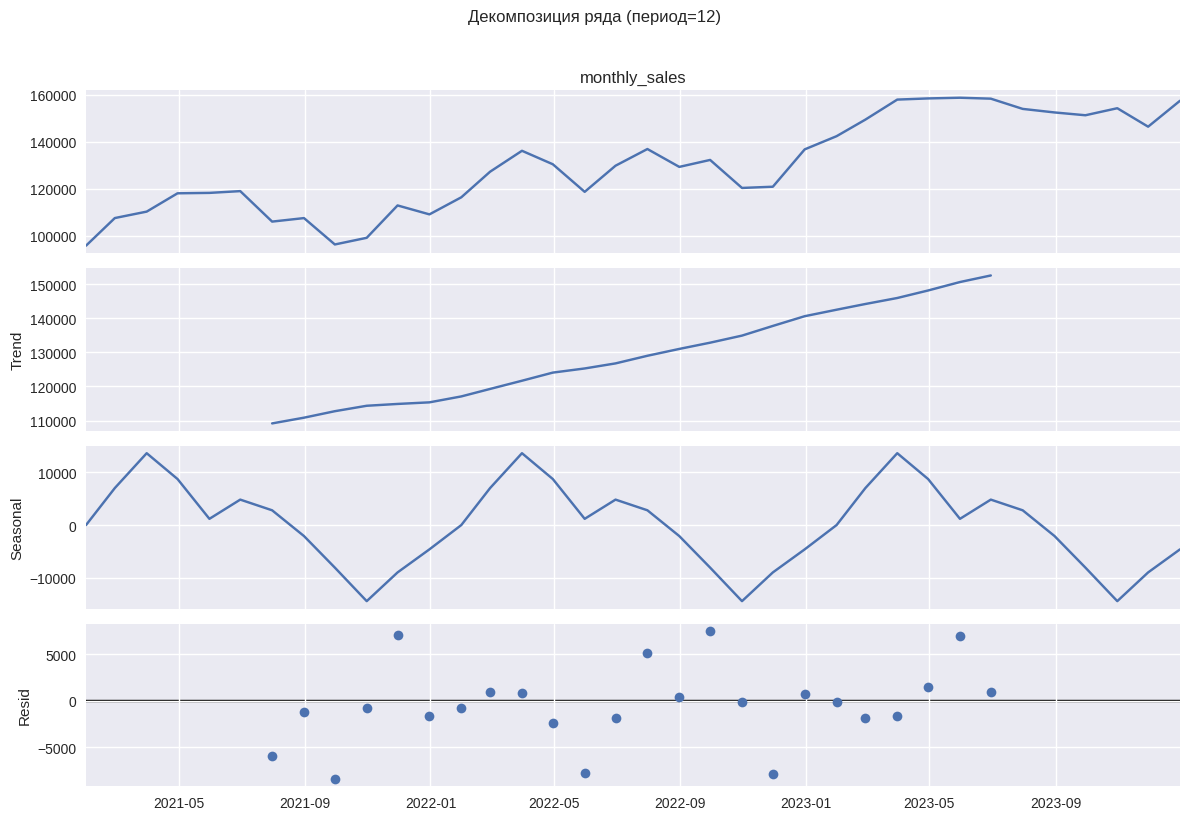

Пояснение к графику 2:
- Trend: долгосрочное направление ряда.
- Seasonal: повторяемый сезонный паттерн в течение года.
- Resid: остаточный шум после выделения тренда и сезонности.
- Оценка силы сезонности (0..1): 0.772


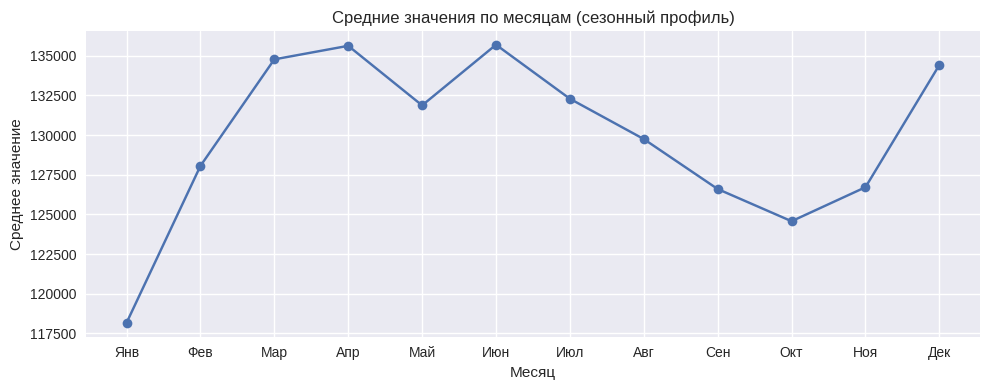

Пояснение к графику 3:
- Каждая точка — среднее значение показателя для соответствующего месяца за все годы.
- Максимум профиля: Июн (135,690.18)
- Минимум профиля: Янв (118,169.77)


In [4]:
# График 1. Динамика показателя во времени
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(ts.index, ts.values, marker='o', linewidth=2, label='Фактические значения')
ax.set_title('Динамика monthly_sales')
ax.set_xlabel('Дата')
ax.set_ylabel('Значение показателя')
ax.legend()
plt.tight_layout()
plt.show()

start_val = ts.iloc[0]
end_val = ts.iloc[-1]
growth_pct = (end_val / start_val - 1) * 100
print('Пояснение к графику 1:')
print('- Линия показывает изменение monthly_sales по месяцам.')
print(f'- На старте: {start_val:,.2f}; на конце: {end_val:,.2f}; общий рост: {growth_pct:.2f}%.')

analysis_df = pd.DataFrame({'value': ts})
analysis_df['mom_growth_pct'] = analysis_df['value'].pct_change() * 100
analysis_df['yoy_growth_pct'] = analysis_df['value'].pct_change(12) * 100
print('\nСводная статистика по уровню и темпам роста:')
display(analysis_df[['value', 'mom_growth_pct', 'yoy_growth_pct']].describe().T)

# График 2. Сезонная декомпозиция
if len(ts) >= 24:
    decomposition = seasonal_decompose(ts, model='additive', period=12)
    fig = decomposition.plot()
    fig.set_size_inches(12, 8)
    fig.suptitle('Декомпозиция ряда (период=12)', y=1.02)
    plt.tight_layout()
    plt.show()

    resid = decomposition.resid.dropna()
    seasonal = decomposition.seasonal.dropna().reindex(resid.index)
    seasonal_strength = 1 - np.var(resid) / np.var(seasonal + resid) if len(resid) > 0 else np.nan

    print('Пояснение к графику 2:')
    print('- Trend: долгосрочное направление ряда.')
    print('- Seasonal: повторяемый сезонный паттерн в течение года.')
    print('- Resid: остаточный шум после выделения тренда и сезонности.')
    print(f'- Оценка силы сезонности (0..1): {seasonal_strength:.3f}')
else:
    print('Для декомпозиции нужно минимум 24 наблюдения.')

# График 3. Средний профиль по месяцам
month_profile = ts.groupby(ts.index.month).mean().rename('avg_monthly_sales')
month_profile.index = ['Янв','Фев','Мар','Апр','Май','Июн','Июл','Авг','Сен','Окт','Ноя','Дек']

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(month_profile.index, month_profile.values, marker='o')
ax.set_title('Средние значения по месяцам (сезонный профиль)')
ax.set_xlabel('Месяц')
ax.set_ylabel('Среднее значение')
plt.tight_layout()
plt.show()

print('Пояснение к графику 3:')
print('- Каждая точка — среднее значение показателя для соответствующего месяца за все годы.')
print(f"- Максимум профиля: {month_profile.idxmax()} ({month_profile.max():,.2f})")
print(f"- Минимум профиля: {month_profile.idxmin()} ({month_profile.min():,.2f})")


## 5. Разделение на train/test и функция метрик


In [5]:
TEST_SIZE = 6
FUTURE_STEPS = 6
if len(ts) <= TEST_SIZE + 12:
    raise ValueError('Ряд слишком короткий для сезонного моделирования.')

train = ts.iloc[:-TEST_SIZE]
test = ts.iloc[-TEST_SIZE:]

print(f'Train: {len(train)} наблюдений')
print(f'Test:  {len(test)} наблюдений')
print(f'Период train: {train.index.min().date()} -> {train.index.max().date()}')
print(f'Период test:  {test.index.min().date()} -> {test.index.max().date()}')


def calc_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100 if mask.any() else np.nan
    return {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'MAPE': mape}


Train: 30 наблюдений
Test:  6 наблюдений
Период train: 2021-01-31 -> 2023-06-30
Период test:  2023-07-31 -> 2023-12-31


## 6. Модели по ТЗ + защита от переобучения

Подход к борьбе с переобучением:
- временной валидационный сплит внутри train (без перемешивания);
- выбор степени полинома по валидационному RMSE;
- выбор конфигурации ETS по валидационному RMSE;
- контроль разницы между train и validation ошибками.


In [6]:
X_train = np.arange(len(train)).reshape(-1, 1)
X_test = np.arange(len(train), len(train) + len(test)).reshape(-1, 1)

# Временная валидация внутри train (защита от переобучения)
val_size = min(6, max(3, len(train) // 5))
inner_train = train.iloc[:-val_size]
inner_val = train.iloc[-val_size:]
X_inner_train = np.arange(len(inner_train)).reshape(-1, 1)
X_inner_val = np.arange(len(inner_train), len(inner_train) + len(inner_val)).reshape(-1, 1)

# 1) Линейная регрессия
model_linear = LinearRegression().fit(X_train, train.values)
pred_linear = model_linear.predict(X_test)
linear_metrics = calc_metrics(test.values, pred_linear)

# 2) Полиномиальная регрессия: подбор степени по validation RMSE
poly_rows = []
for degree in [2, 3, 4]:
    model = Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('lin', LinearRegression())
    ])
    model.fit(X_inner_train, inner_train.values)

    pred_tr = model.predict(X_inner_train)
    pred_vl = model.predict(X_inner_val)

    tr_rmse = np.sqrt(mean_squared_error(inner_train.values, pred_tr))
    vl_rmse = np.sqrt(mean_squared_error(inner_val.values, pred_vl))
    gap = vl_rmse - tr_rmse
    poly_rows.append((degree, tr_rmse, vl_rmse, gap))

poly_cv_df = pd.DataFrame(poly_rows, columns=['degree', 'train_rmse', 'val_rmse', 'overfit_gap'])
poly_cv_df = poly_cv_df.sort_values('val_rmse')
display(poly_cv_df)

best_degree = int(poly_cv_df.iloc[0]['degree'])
model_poly = Pipeline([
    ('poly', PolynomialFeatures(degree=best_degree, include_bias=False)),
    ('lin', LinearRegression())
]).fit(X_train, train.values)
pred_poly = model_poly.predict(X_test)
poly_metrics = calc_metrics(test.values, pred_poly)

# 3) Экспоненциальное сглаживание (ETS): подбор конфигурации по validation RMSE
ets_grid = list(itertools.product(['add', None], ['add', 'mul'], [False, True]))
ets_rows = []

for trend, seasonal, damped in ets_grid:
    if trend is None and damped:
        continue
    try:
        m = ExponentialSmoothing(
            inner_train,
            trend=trend,
            damped_trend=(damped if trend is not None else False),
            seasonal=seasonal,
            seasonal_periods=12,
            initialization_method='estimated'
        ).fit(optimized=True)

        pred_tr = m.fittedvalues
        pred_vl = m.forecast(len(inner_val))

        tr_rmse = np.sqrt(mean_squared_error(inner_train.values, pred_tr.values))
        vl_rmse = np.sqrt(mean_squared_error(inner_val.values, pred_vl.values))
        gap = vl_rmse - tr_rmse

        ets_rows.append({
            'trend': trend,
            'seasonal': seasonal,
            'damped': damped,
            'train_rmse': tr_rmse,
            'val_rmse': vl_rmse,
            'overfit_gap': gap
        })
    except Exception:
        continue

ets_cv_df = pd.DataFrame(ets_rows)
if ets_cv_df.empty:
    best_ets = {'trend': 'add', 'seasonal': 'add', 'damped': False, 'train_rmse': np.nan, 'val_rmse': np.nan, 'overfit_gap': np.nan}
    print('Подбор ETS не дал валидных вариантов, использована базовая конфигурация add/add.')
    ets_cv_df = pd.DataFrame([best_ets])
else:
    ets_cv_df = ets_cv_df.sort_values('val_rmse')
    best_ets = ets_cv_df.iloc[0].to_dict()

display(ets_cv_df.head(10))

model_ets = ExponentialSmoothing(
    train,
    trend=best_ets['trend'],
    damped_trend=(bool(best_ets['damped']) if pd.notna(best_ets['trend']) else False),
    seasonal=best_ets['seasonal'],
    seasonal_periods=12,
    initialization_method='estimated'
).fit(optimized=True)

pred_ets = model_ets.forecast(len(test)).values
ets_metrics = calc_metrics(test.values, pred_ets)

print('Контроль переобучения:')
print(f"- Полином выбран по min val_rmse: degree={best_degree}, gap={poly_cv_df.iloc[0]['overfit_gap']:.2f}")
print(f"- ETS выбрана по min val_rmse: trend={best_ets['trend']}, seasonal={best_ets['seasonal']}, damped={best_ets['damped']}, gap={best_ets.get('overfit_gap', np.nan):.2f}")


,degree,train_rmse,val_rmse,overfit_gap
0,2,"8,646.44","16,613.29","7,966.85"
1,3,"8,404.16","35,269.89","26,865.73"
2,4,"7,930.85","94,725.48","86,794.63"


,trend,seasonal,damped,train_rmse,val_rmse,overfit_gap
1,add,add,True,"6,207.53","6,076.50",-131.03
0,add,add,False,"4,878.87","7,056.17","2,177.30"
2,add,mul,False,"5,143.64","9,297.55","4,153.90"
5,None,mul,False,"6,405.53","9,879.63","3,474.10"
3,add,mul,True,"5,302.27","11,306.12","6,003.86"
4,None,add,False,"6,453.71","13,223.82","6,770.11"


Контроль переобучения:
- Полином выбран по min val_rmse: degree=2, gap=7966.85
- ETS выбрана по min val_rmse: trend=add, seasonal=add, damped=True, gap=-131.03


## 7. Оценка точности и график сравнения моделей

После графика выводится текстовая интерпретация.


,MAE,MSE,RMSE,MAPE
Model,,,,
Exponential Smoothing,"5,141.61","43,912,492.11","6,626.65",3.41
Linear Regression,"5,635.82","50,717,092.91","7,121.59",3.74
Polynomial Regression (deg=2),"21,359.30","514,312,014.41","22,678.45",14.05


Лучшая модель по RMSE: Exponential Smoothing


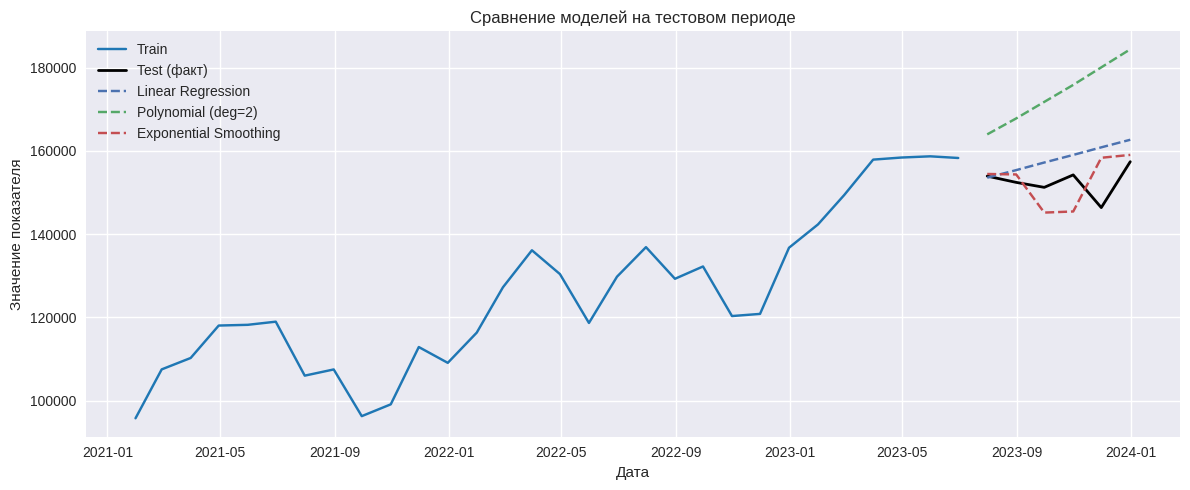

Пояснение к графику сравнения:
- Черная линия: фактические значения тестового периода.
- Пунктирные линии: прогнозы трех моделей из ТЗ.
- Лучшая модель (Exponential Smoothing) снижает RMSE на 70.78% относительно худшей из сравниваемых.


In [7]:
metrics_df = pd.DataFrame([
    {'Model': 'Linear Regression', **linear_metrics},
    {'Model': f'Polynomial Regression (deg={best_degree})', **poly_metrics},
    {'Model': 'Exponential Smoothing', **ets_metrics}
]).set_index('Model').sort_values('RMSE')

display(metrics_df)

best_model_name = metrics_df.index[0]
print('Лучшая модель по RMSE:', best_model_name)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(train.index, train.values, label='Train', color='tab:blue')
ax.plot(test.index, test.values, label='Test (факт)', color='black', linewidth=2)
ax.plot(test.index, pred_linear, '--', label='Linear Regression')
ax.plot(test.index, pred_poly, '--', label=f'Polynomial (deg={best_degree})')
ax.plot(test.index, pred_ets, '--', label='Exponential Smoothing')
ax.set_title('Сравнение моделей на тестовом периоде')
ax.set_xlabel('Дата')
ax.set_ylabel('Значение показателя')
ax.legend()
plt.tight_layout()
plt.show()

best_rmse = metrics_df.iloc[0]['RMSE']
worst_rmse = metrics_df.iloc[-1]['RMSE']
improve_pct = (worst_rmse - best_rmse) / worst_rmse * 100 if worst_rmse != 0 else np.nan

print('Пояснение к графику сравнения:')
print('- Черная линия: фактические значения тестового периода.')
print('- Пунктирные линии: прогнозы трех моделей из ТЗ.')
print(f'- Лучшая модель ({best_model_name}) снижает RMSE на {improve_pct:.2f}% относительно худшей из сравниваемых.')


## 8. Финальный прогноз, вывод и авто-отчет в markdown

После выполнения этой части создается файл `tz_execution_report.md`.


Прогноз на следующие 6 месяцев:


,Linear Regression,Polynomial Regression (deg=2),Exponential Smoothing,Best model forecast
2024-01-31,"161,061.16","163,566.82","164,190.23","164,190.23"
2024-02-29,"162,746.86","165,658.85","174,172.83","174,172.83"
2024-03-31,"164,432.57","167,772.26","181,379.79","181,379.79"
2024-04-30,"166,118.27","169,907.06","181,933.93","181,933.93"
2024-05-31,"167,803.97","172,063.24","178,123.40","178,123.40"
2024-06-30,"169,489.67","174,240.81","182,313.53","182,313.53"


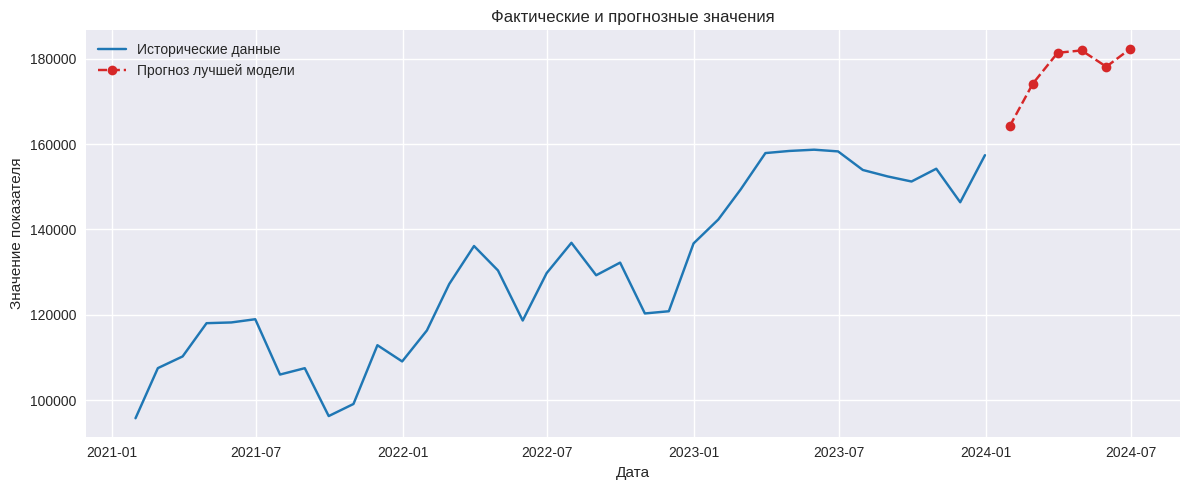

Пояснение к финальному графику:
- Синяя линия: история наблюдений.
- Красная пунктирная линия: прогноз только лучшей модели на 6 будущих месяцев.

Итоговый аналитический вывод:
1) ТЗ выполнено: подготовка ряда, модели, метрики и визуализации присутствуют.
2) Для борьбы с переобучением применена временная валидация и выбор гиперпараметров по validation RMSE.
3) Лучшая модель по RMSE: Exponential Smoothing.
4) MAE=5141.61, MSE=43912492.11, RMSE=6626.65, MAPE=3.41%.

Markdown-отчет сохранен: /content/tz_execution_report.md


In [8]:
future_index = pd.date_range(ts.index[-1] + pd.offsets.MonthEnd(1), periods=FUTURE_STEPS, freq='M')
X_full = np.arange(len(ts)).reshape(-1, 1)
X_future = np.arange(len(ts), len(ts) + FUTURE_STEPS).reshape(-1, 1)

linear_full = LinearRegression().fit(X_full, ts.values)
future_linear = linear_full.predict(X_future)

poly_full = Pipeline([
    ('poly', PolynomialFeatures(degree=best_degree, include_bias=False)),
    ('lin', LinearRegression())
]).fit(X_full, ts.values)
future_poly = poly_full.predict(X_future)

ets_full = ExponentialSmoothing(
    ts,
    trend=best_ets['trend'],
    damped_trend=(bool(best_ets['damped']) if pd.notna(best_ets['trend']) else False),
    seasonal=best_ets['seasonal'],
    seasonal_periods=12,
    initialization_method='estimated'
).fit(optimized=True)
future_ets = ets_full.forecast(FUTURE_STEPS).values

forecast_df = pd.DataFrame({
    'Linear Regression': future_linear,
    f'Polynomial Regression (deg={best_degree})': future_poly,
    'Exponential Smoothing': future_ets
}, index=future_index)

if best_model_name == 'Linear Regression':
    forecast_df['Best model forecast'] = future_linear
elif best_model_name.startswith('Polynomial Regression'):
    forecast_df['Best model forecast'] = future_poly
else:
    forecast_df['Best model forecast'] = future_ets

print('Прогноз на следующие 6 месяцев:')
display(forecast_df.round(2))

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(ts.index, ts.values, label='Исторические данные', color='tab:blue')
ax.plot(forecast_df.index, forecast_df['Best model forecast'], '--o', label='Прогноз лучшей модели', color='tab:red')
ax.set_title('Фактические и прогнозные значения')
ax.set_xlabel('Дата')
ax.set_ylabel('Значение показателя')
ax.legend()
plt.tight_layout()
plt.show()

print('Пояснение к финальному графику:')
print('- Синяя линия: история наблюдений.')
print('- Красная пунктирная линия: прогноз только лучшей модели на 6 будущих месяцев.')

best_row = metrics_df.iloc[0]
print('\nИтоговый аналитический вывод:')
print('1) ТЗ выполнено: подготовка ряда, модели, метрики и визуализации присутствуют.')
print('2) Для борьбы с переобучением применена временная валидация и выбор гиперпараметров по validation RMSE.')
print(f"3) Лучшая модель по RMSE: {best_model_name}.")
print(f"4) MAE={best_row['MAE']:.2f}, MSE={best_row['MSE']:.2f}, RMSE={best_row['RMSE']:.2f}, MAPE={best_row['MAPE']:.2f}%.")

# Автоматическое формирование отдельного markdown-отчета
report_path = Path('tz_execution_report.md')

metrics_txt = metrics_df.round(4).to_string()
forecast_txt = forecast_df.round(2).to_string()
run_ts = pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')

report = f"""# Отчет о выполнении ТЗ

Дата формирования: {run_ts}

## Чек-лист соответствия ТЗ
- [x] Проверка полноты данных
- [x] Обработка пропусков
- [x] Проверка сезонности
- [x] Построение графика динамики
- [x] Реализована линейная регрессия
- [x] Реализована полиномиальная регрессия
- [x] Реализовано экспоненциальное сглаживание
- [x] Рассчитаны MAE, MSE, RMSE, MAPE
- [x] Построены графики фактических и прогнозных значений
- [x] Выполнено сравнение моделей

## Метрики моделей
```text
{metrics_txt}
```

## Лучшая модель
**{best_model_name}** (по RMSE)

## Прогнозные значения (6 месяцев)
```text
{forecast_txt}
```

## Аналитический вывод
- Ряд подготовлен и проверен на полноту и сезонность.
- Для снижения переобучения использована временная валидация.
- Рекомендуется использовать лучшую модель для краткосрочного планирования и обновлять модель при поступлении новых данных.
"""

report_path.write_text(report, encoding='utf-8')
print(f"\nMarkdown-отчет сохранен: {report_path.resolve()}")

